In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp

# Normalizing flows

Constructing normalizing flows easily using the inverse interpreter!

In [2]:
input_dim = 2

In [3]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

I0000 00:00:1701024330.353054   96657 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-11-26 19:45:30.543709: W external/xla/xla/service/platform_util.cc:198] unable to create StreamExecutor for CUDA:0: failed initializing StreamExecutor for CUDA device ordinal 0: INTERNAL: failed call to cuDevicePrimaryCtxRetain: CUDA_ERROR_OUT_OF_MEMORY: out of memory; total memory reported: 11554848768


In [ ]:
# Mixture of Gaussians target distribution

target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


### Affine flows

We have a coupling MLP combined with an affine bijector.

In [ ]:
@jax.vmap
def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale) + 0.5
    return loc + scale*x


bijector_dim = 2*input_dim
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([AutoregressiveMLP(affine_bijector, bijector_dim),
                        Flip(), 
                        AutoregressiveMLP(affine_bijector, bijector_dim), 
    ])
    return nn(x)

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((1, input_dim)))

# Parameterized invertibe transformation
T = forward.apply

ValueError: 'masked_mlp/~/linear_0/b' with retrieved shape (1, 2) does not match shape=[50] dtype=dtype('float32')

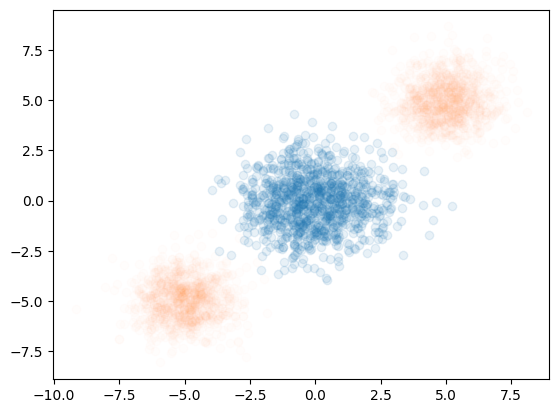

In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [ ]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [ ]:
# TODO The inverse of a custom inverse should be a custom inverse!

In [ ]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

20.239792
3.9542706
3.7857623
3.7018244
3.6634827


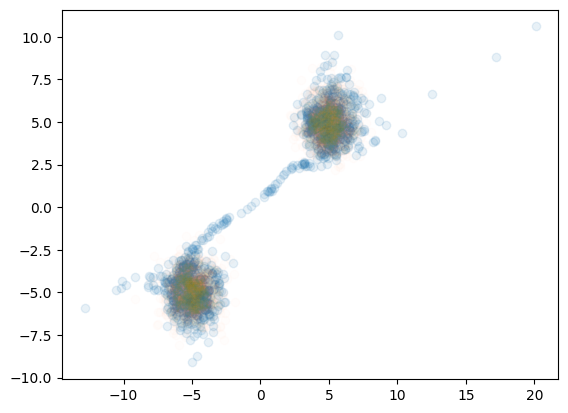

In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)